# 05 Water Access

**Project:** Pine Ridge Bison Habitat Suitability Analysis  
**BHSI Component:** Water Access (25% weight)  
**Data Source:** USGS NHDPlus HR streams and water bodies

## Water as a Hard Constraint

Water access receives the second-highest weight (25%) in the BHSI because
it is a near-hard constraint for bison management on Pine Ridge.

Bison drink daily, typically consuming 30–50 liters per animal per day in
summer. On the Northern Great Plains, surface water is scarce and seasonal.
Land beyond reliable water access cannot sustain a bison herd year-round
regardless of forage quality.

The standard rule of thumb used by range managers: bison on open range
will travel up to 5km from water. Beyond that distance, they will seek
other water sources or simply avoid the area during dry periods.

This notebook computes a Euclidean distance raster from each pixel to
the nearest NHD stream, pond, or water body, then converts distance
to a suitability score.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import warnings
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio

from src.constants import (
    CRS_PROJECTED, PINE_RIDGE_BBOX,
    WATER_DISTANCE_MAX_M, CACHE_DIR, OUTPUTS_DIR, FIGURES_DIR,
)
from src.loaders import load_nhd_water_features
from src.raster_utils import compute_distance_raster, normalize_0_1
from src.sovereignty import print_data_acknowledgment, generate_citations

warnings.filterwarnings("ignore")
%matplotlib inline

TEMPLATE_PATH = CACHE_DIR/"template_30m_albers.tif"
assert TEMPLATE_PATH.exists(), "Run notebook 01 first."
pine_ridge = gpd.read_file(OUTPUTS_DIR/"pine_ridge_boundary.geojson")
print("Setup complete.")
print(f"Water distance maximum: {WATER_DISTANCE_MAX_M:,}m ({WATER_DISTANCE_MAX_M/1000:.0f}km)")

Setup complete.
Water distance maximum: 5,000m (5km)


In [2]:
# Print the data sovereignty statement at the top of every notebook
print_data_acknowledgment(source_keys=["nhd"])


PINE RIDGE BISON HABITAT ANALYSIS DATA GOVERNANCE ACKNOWLEDGMENT
This analysis describes land within the Pine Ridge Reservation, home of
the Oglala Lakota Nation. Bison (Pte Oyate) hold deep cultural, spiritual,
and ecological significance for the Oglala Lakota people. This analysis
exists to support Tribal land stewardship, not to define it.

Results should be understood as one input into a land management
conversation, not as a determination of where bison belong.
That determination rests with the Oglala Lakota Nation.

GOVERNANCE FRAMEWORKS:

OCAP®  : The Oglala Lakota Nation has Ownership, Control, Access, and
  Possession of data describing their land and resources. Analysis results
  derived from public federal data about Pine Ridge still carry this
  obligation. Share results with OLC Cubedynamics and the relevant
  Oglala Lakota Nation land management offices before external distribution.
  Reference: https://fnigc.ca/ocap-training/

CARE   : Analysis must deliver Collective B

## Load NHD Water Features

In [3]:
streams, waterbodies = load_nhd_water_features(bbox=PINE_RIDGE_BBOX)

print(f"Streams     : {len(streams):,} features")
print(f"Water bodies: {len(waterbodies):,} features")

if not streams.empty and "streamorde" in streams.columns:
    print("\nStream order distribution:")
    print(streams["streamorde"].value_counts().sort_index().to_string())

if not waterbodies.empty and "ftype" in waterbodies.columns:
    print("\nWater body types:")
    print(waterbodies["ftype"].value_counts().to_string())

  Streams: 2,000 features
  Water bodies: 186 features
Streams     : 2,000 features
Water bodies: 186 features

Stream order distribution:
streamorde
1    1006
2     576
3     217
4     116
5      42
6      18
7       4
9      21

Water body types:
ftype
343    130
411     55
362      1


In [4]:
# Combine all water features into a single GeoDataFrame
water_parts = []
if not streams.empty:
    water_parts.append(streams[["geometry"]])
if not waterbodies.empty:
    water_parts.append(waterbodies[["geometry"]])

if water_parts:
    import pandas as pd
    all_water = pd.concat(water_parts, ignore_index=True)
    all_water = gpd.GeoDataFrame(all_water, crs=streams.crs if not streams.empty
                                 else waterbodies.crs)
    all_water = all_water.to_crs(CRS_PROJECTED)
    print(f"Combined water features: {len(all_water):,}")
    WATER_AVAILABLE = True
else:
    print("No NHD water features found.")
    print("Pine Ridge has limited mapped surface water so this is expected.")
    print("Bison water infrastructure (tanks, ponds) would need to be added")
    print("from Tribal data sources if available.")
    WATER_AVAILABLE = False

Combined water features: 2,186


## Compute Distance-to-Water Raster

In [5]:
water_dist_path  = CACHE_DIR/"water_distance_m.tif"
water_suit_path  = OUTPUTS_DIR/"bhsi_water.tif"

with rasterio.open(TEMPLATE_PATH) as tmpl:
    tmpl_data  = tmpl.read(1)
    profile    = tmpl.profile.copy()
    tmpl_shape = (tmpl.height, tmpl.width)
    tmpl_trans = tmpl.transform

if WATER_AVAILABLE:
    compute_distance_raster(
        features_gdf  = all_water,
        template_path = TEMPLATE_PATH,
        output_path   = water_dist_path,
        max_dist_m    = None,
    )
    with rasterio.open(water_dist_path) as src:
        dist_m = src.read(1)

    print(f"Distance raster statistics:")
    valid_d = dist_m[~np.isnan(dist_m)]
    print(f"  Min: {np.nanmin(dist_m):.0f}m")
    print(f"  Max: {np.nanmax(dist_m):.0f}m")
    print(f"  Mean: {np.nanmean(dist_m):.0f}m")
    pct_in_range = (valid_d <= WATER_DISTANCE_MAX_M).mean() * 100
    print(f"  Within {WATER_DISTANCE_MAX_M/1000:.0f}km of water: {pct_in_range:.1f}% of pixels")
else:
    # Fallback: moderate uniform score
    dist_m = np.where(~np.isnan(tmpl_data), 2500.0, np.nan).astype(np.float32)
    print("Using fallback distance of 2500m (moderate access)")

Distance raster statistics:
  Min: 0m
  Max: 25030m
  Mean: 4654m
  Within 5km of water: 73.4% of pixels


In [6]:
# Convert distance to suitability score
# Score function:
#   0–1km: 1.0 (excellent — at or near water)
#   1–3km: linear decline to 0.5
#   3–5km: linear decline to 0.05
#   >5km:  0.0 (beyond practical bison range)

km1, km3, km5 = 1000, 3000, WATER_DISTANCE_MAX_M

water_suit = np.where(
    dist_m <= km1, 1.0,
    np.where(
        dist_m <= km3,
        1.0 - 0.5 * (dist_m - km1) / (km3 - km1),
        np.where(
            dist_m <= km5,
            0.5 - 0.45 * (dist_m - km3) / (km5 - km3),
            0.0
        )
    )
).astype(np.float32)

water_suit[np.isnan(tmpl_data)] = np.nan

with rasterio.open(water_suit_path, "w", **profile) as dst:
    dst.write(water_suit, 1)

valid = water_suit[~np.isnan(water_suit)]
print(f"Water access suitability layer:")
print(f"  Mean  : {valid.mean():.3f}")
print(f"  Pixels with score >= 0.8 (within ~1km of water): {(valid >= 0.8).mean()*100:.1f}%")
print(f"  Pixels with score < 0.1 (beyond 5km): {(valid < 0.1).mean()*100:.1f}%")
print(f"  Saved : outputs/bhsi_water.tif")

Water access suitability layer:
  Mean  : 0.480
  Pixels with score >= 0.8 (within ~1km of water): 27.4%
  Pixels with score < 0.1 (beyond 5km): 28.2%
  Saved : outputs/bhsi_water.tif


## Visualization

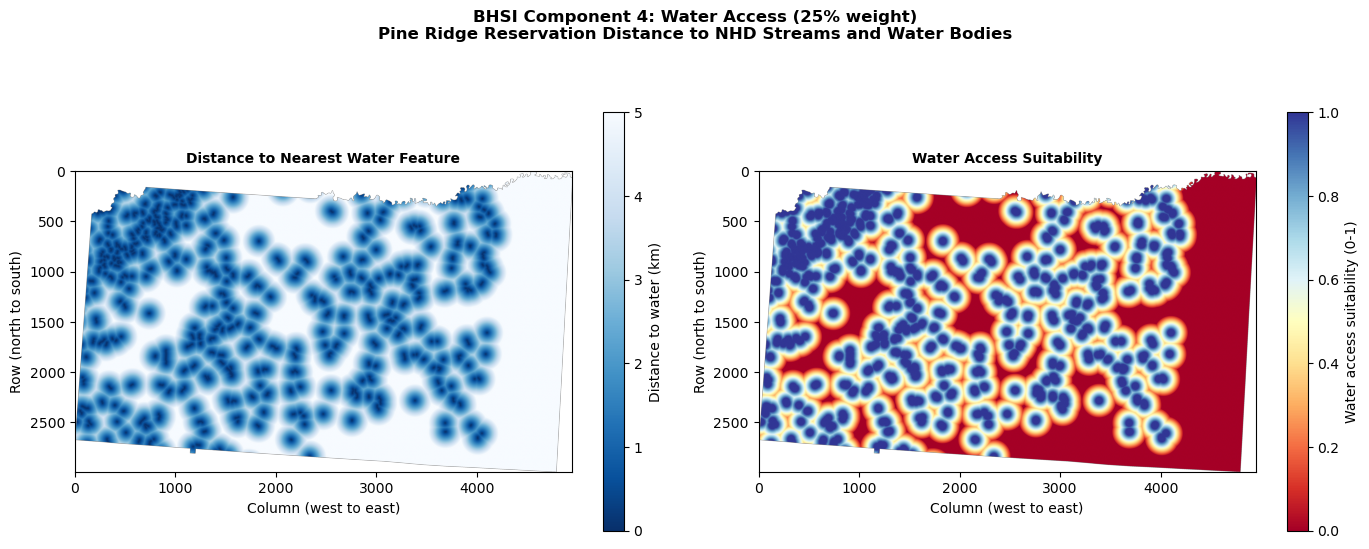

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

im0 = axes[0].imshow(
    np.where(np.isnan(tmpl_data), np.nan, dist_m / 1000),
    cmap="Blues_r", vmin=0, vmax=WATER_DISTANCE_MAX_M/1000, origin="upper",
)
plt.colorbar(im0, ax=axes[0], label="Distance to water (km)", shrink=0.8)
axes[0].set_title("Distance to Nearest Water Feature", fontsize=10, fontweight="bold")

im1 = axes[1].imshow(water_suit, cmap="RdYlBu", vmin=0, vmax=1, origin="upper")
plt.colorbar(im1, ax=axes[1], label="Water access suitability (0-1)", shrink=0.8)
axes[1].set_title("Water Access Suitability", fontsize=10, fontweight="bold")

for ax in axes:
    ax.set_xlabel("Column (west to east)")
    ax.set_ylabel("Row (north to south)")

plt.suptitle(
    "BHSI Component 4: Water Access (25% weight)\n"
    "Pine Ridge Reservation Distance to NHD Streams and Water Bodies",
    fontsize=12, fontweight="bold",
)
plt.tight_layout()
fig.savefig(FIGURES_DIR/"05_water_access.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
print(generate_citations(["nhd"]))

DATA CITATIONS

USGS National Hydrography Dataset (NHD) Plus HR
  https://www.usgs.gov/national-hydrography/nhdplus-high-resolution
  Steward: US Geological Survey | License: Public domain (USGS)

Governance: OCAP® | CARE | FAIR | IEEE 2890-2025
  OCAP: https://fnigc.ca/ocap-training/
  CARE: https://www.gida-global.org/care
  FAIR: https://www.go-fair.org/fair-principles/
  IEEE_2890: https://standards.ieee.org/ieee/2890/10318/
